# Actor Crtic for Continous Action Environment

In this notebook, we will implement Actor Critic algorithm for Mountain car continous Environment.

## Mountain Car

The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill. There are two versions of the mountain car domain in gymnasium: one with discrete actions and one with continuous. We will experiment with the continouse version in this one.


![Mountain Car](https://gymnasium.farama.org/_images/mountain_car_continuous.gif)

The observation is a ndarray with shape (2,) where the elements correspond to the position of the car along the x-axis and the velocity of the car.

The action is a ndarray with shape (1,), representing the directional force applied on the car. The action is clipped in the range [-1,1] and multiplied by a power of 0.0015.

A negative reward of $-0.1 * action^2$ is received at each timestep to penalise for taking actions of large magnitude. If the mountain car reaches the goal then a positive reward of +100 is added to the negative reward for that timestep.

You can read more the MountainCar Continous environment [here](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/)

## Continous Action Spaces

It's conceptually the same as for discrete action spaces. In discrete action spaces you have a discrete distribution like the categorical distribution and you calculate the log pi probabilities using its mass function. In continuous action spaces you use a continuous distribution like the Gaussian distribution and calculate the log pi “probabilities” using its density function. Everything else is the same.

So instead of having network that outputs the parameters for a categorical distribution, you have a network that outputs parameters for (usually) a Gaussian distribution (i.e. the mean and standard deviation)

But, usually we just output the mean using a neural network, and have a separate set of learnable parameters for std (in log space) for each action. For example, if we 3 continous actions then we will have a neural network which will output the means for these actions and then separate 3 parameters which will represent the log std of these actions. We still learn these log std but they are not dependent on state. We just have a log std for each action.

Other approaches for std include:
- Having a std as output of neural network just as the mean.
- Initializing some std for all actions at start and then steadily decrease if using a std_decay hyperparameter as the training progresses.


You can use any appraoch you like.



## Reward Function

As mentioned above, s negative reward of $-0.1 * action^2$ is received at each timestep to penalise for taking actions of large magnitude. If the mountain car reaches the goal then a positive reward of +100 is added to the negative reward for that timestep.

However, you can change this reward function and write a custom one if you like and think it will make the agent learn better.

## Actor Critic Methods

Actor-Critic methods are [temporal difference (TD) learning](https://en.wikipedia.org/wiki/Temporal_difference_learning) methods that represent the policy function independent of the value function.

A policy function (or policy) returns a probability distribution over actions that the agent can take based on the given state.
A value function determines the expected return for an agent starting at a given state and acting according to a particular policy forever after.

In the Actor-Critic method, the policy is referred to as the *actor* that proposes a set of possible actions given a state, and the estimated value function is referred to as the *critic*, which evaluates actions taken by the *actor* based on the given policy.

In this tutorial, both the *Actor* and *Critic* will be represented using one neural network with two outputs.




### 3. The Actor-Critic loss

Since you're using a hybrid Actor-Critic model, the chosen loss function is a combination of Actor and Critic losses for training, as shown below:

$$L = L_{actor} + L_{critic}$$

#### The Actor loss

The Actor loss is based on [policy gradients with the Critic as a state dependent baseline](https://www.youtube.com/watch?v=EKqxumCuAAY&t=62m23s) and computed with single-sample (per-episode) estimates.

$$L_{actor} = -\sum^{T}_{t=1} \log\pi_{\theta}(a_{t} | s_{t})[G(s_{t}, a_{t})  - V^{\pi}_{\theta}(s_{t})]$$

where:
- $T$: the number of timesteps per episode, which can vary per episode
- $s_{t}$: the state at timestep $t$
- $a_{t}$: chosen action at timestep $t$ given state $s$
- $\pi_{\theta}$: is the policy (Actor) parameterized by $\theta$
- $V^{\pi}_{\theta}$: is the value function (Critic) also parameterized by $\theta$
- $G = G_{t}$: the expected return for a given state, action pair at timestep $t$

A negative term is added to the sum since the idea is to maximize the probabilities of actions yielding higher rewards by minimizing the combined loss.

<br>

##### The Advantage

The $G - V$ term in our $L_{actor}$ formulation is called the [Advantage](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html#advantage-functions), which indicates how much better an action is given a particular state over a random action selected according to the policy $\pi$ for that state.

While it's possible to exclude a baseline, this may result in high variance during training. And the nice thing about choosing the critic $V$ as a baseline is that it trained to be as close as possible to $G$, leading to a lower variance.

In addition, without the Critic, the algorithm would try to increase probabilities for actions taken on a particular state based on expected return, which may not make much of a difference if the relative probabilities between actions remain the same.

For instance, suppose that two actions for a given state would yield the same expected return. Without the Critic, the algorithm would try to raise the probability of these actions based on the objective $J$. With the Critic, it may turn out that there's no Advantage ($G - V = 0$), and thus no benefit gained in increasing the actions' probabilities and the algorithm would set the gradients to zero.

Due to the usage of this advantage function, this algorithm is also **Advantage Actor Critic (A2C)**.
<br>

#### The Critic loss

Training $V$ to be as close possible to $G$ can be set up as a regression problem with the following loss function:

$$L_{critic} = L_{\delta}(G, V^{\pi}_{\theta})$$

where $L_{\delta}$ is the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss), which is less sensitive to outliers in data than squared-error loss.


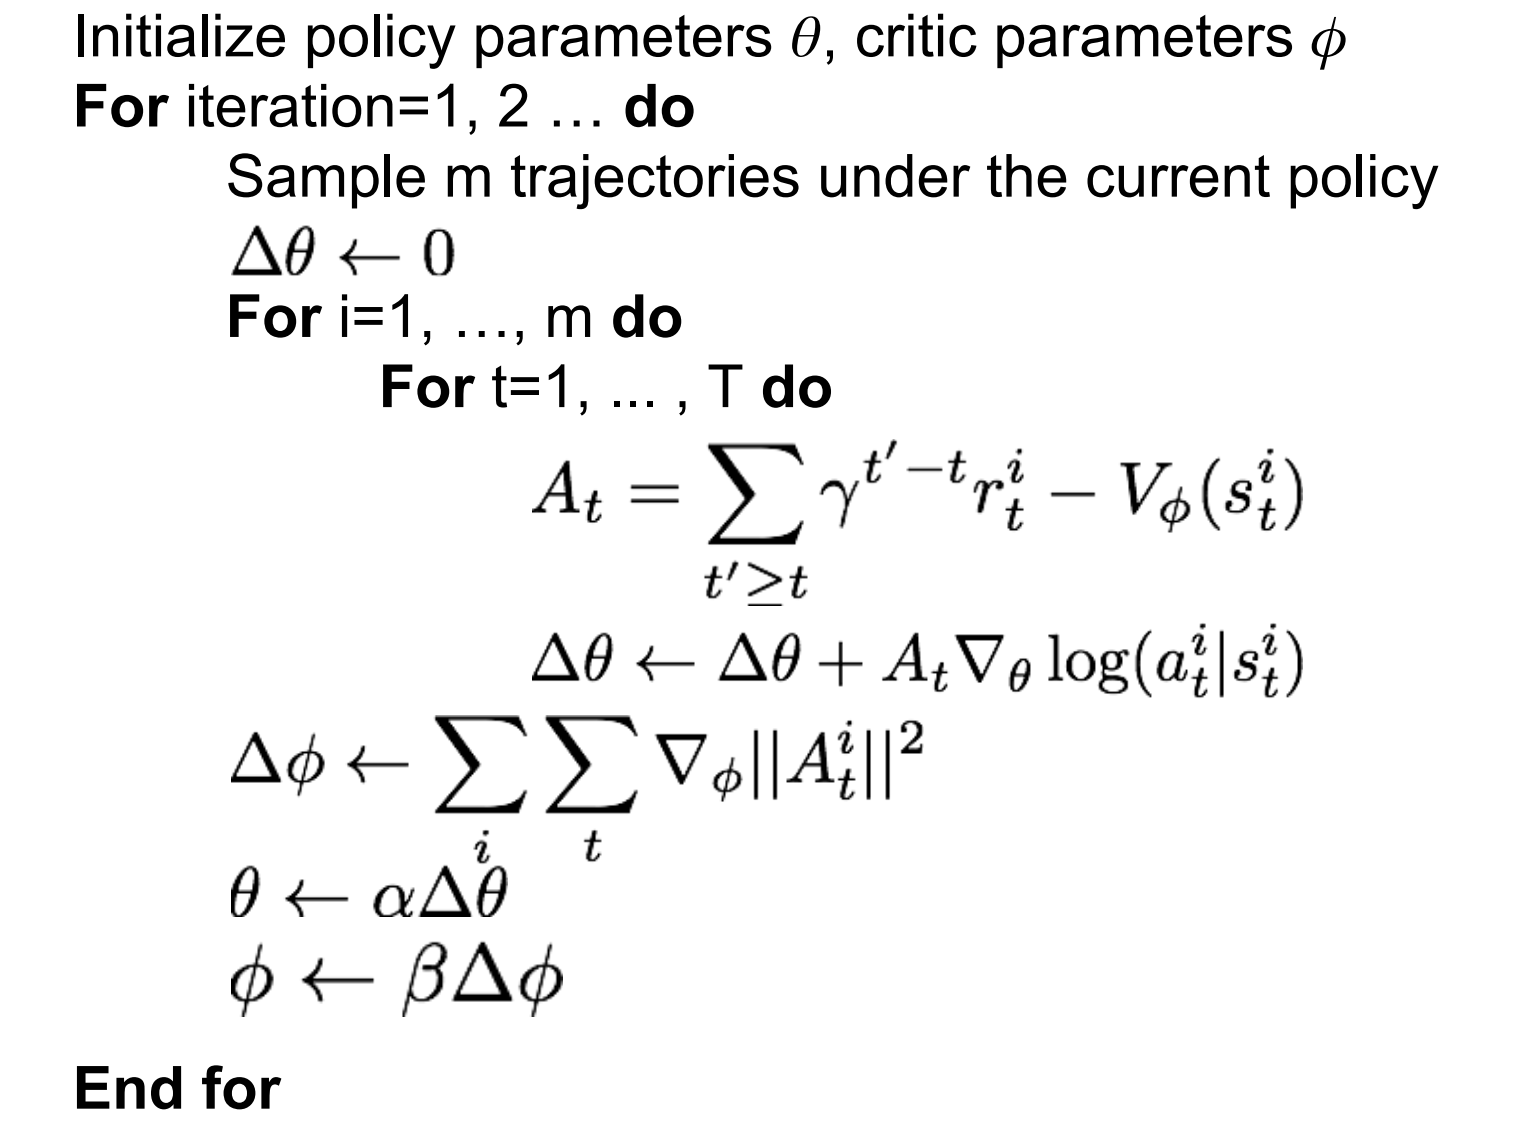

[Image Source](http://cs231n.stanford.edu/slides/2017/cs231n_2017_lecture14.pdf)

In [20]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Normal


In [21]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
# Create the environment
env = gym.make('MountainCarContinuous-v0')

### Network

In [23]:
# [ADDED] Actor Network — outputs mean and std of a Gaussian policy (continuous actions)
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(ActorNetwork, self).__init__()
        # [ADDED] Shared feature extractor
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)        # [ADDED] outputs Gaussian mean
        self.log_std   = nn.Parameter(torch.zeros(action_dim))    # [ADDED] learnable log std

    def forward(self, x):
        shared = self.shared(x)
        mean   = torch.tanh(self.mean_head(shared))  # [ADDED] tanh clips output to [-1, 1]
        std    = self.log_std.clamp(-20, 2).exp().expand_as(mean)  # [ADDED] clamp prevents nan from diverging log_std
        return mean, std


# [ADDED] Critic Network — estimates state value V(s)
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=256):
        super(CriticNetwork, self).__init__()
        # [ADDED] MLP with two hidden layers; outputs scalar V(s)
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)  # [ADDED] scalar state value estimate


### Hyperparameters

In [24]:
# [ADDED] Hyperparameters for Actor-Critic on MountainCarContinuous-v0
LEARNING_RATE = 1e-3    # [ADDED]
NUM_EPISODES  = 3000    # [ADDED] increased — MountainCar needs more episodes
GAMMA         = 0.99    # [ADDED] discount factor
MAX_STEPS     = 1000    # [ADDED] max steps per episode
ENTROPY_COEF  = 0.1     # [ADDED] entropy bonus — increased for more exploration


### Training

In [25]:
# [ADDED] Initialize networks and optimizers
state_dim  = env.observation_space.shape[0]   # [ADDED] 2 for MountainCarContinuous
action_dim = env.action_space.shape[0]         # [ADDED] 1 for MountainCarContinuous

actor      = ActorNetwork(state_dim, action_dim).to(device)     # [ADDED]
critic     = CriticNetwork(state_dim).to(device)                # [ADDED]
actor_opt  = optim.Adam(actor.parameters(),  lr=LEARNING_RATE)  # [ADDED]
critic_opt = optim.Adam(critic.parameters(), lr=LEARNING_RATE)  # [ADDED]

# [ADDED] Start log_std at 0.5 so std ~ 1.65 — more exploration early on
with torch.no_grad():
    actor.log_std.fill_(0.5)  # [ADDED]

scores = []   # [ADDED] used by the plotting cell below

# [ADDED] Helper: potential-based reward shaping
# phi(s) = position + 0.5 * |velocity| — gives a denser progress signal
# F(s,s') = gamma*phi(s') - phi(s) is added to the environment reward
def shape_reward(state, next_state, reward, gamma):
    phi_curr = 3.0 * state[0]      + state[1]**2       # [ADDED] stronger position signal
    phi_next = 3.0 * next_state[0] + next_state[1]**2  # [ADDED]
    return reward + gamma * phi_next - phi_curr         # [ADDED]

# [ADDED] Training loop — Actor-Critic with TD error + reward shaping + entropy bonus
for episode in range(NUM_EPISODES):
    state, _ = env.reset()   # [ADDED] gymnasium API
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)

        # [ADDED] Actor: sample action from Gaussian policy
        mean, std = actor(state_t)
        dist      = torch.distributions.Normal(mean, std)
        action    = dist.sample()
        log_prob  = dist.log_prob(action).sum(-1)     # [ADDED] compute before clamping
        action    = action.clamp(-1.0, 1.0)           # [ADDED] clip to action bounds
        entropy   = dist.entropy().sum(-1)            # [ADDED] for entropy bonus

        # [ADDED] Critic: estimate current state value V(s)
        value = critic(state_t)

        # [ADDED] Take step in environment
        next_state, reward, terminated, truncated, _ = env.step(
            action.cpu().detach().numpy()[0]
        )
        done = terminated or truncated   # [ADDED]

        # [ADDED] Apply reward shaping to give denser learning signal
        shaped_r = shape_reward(state, next_state, reward, GAMMA)  # [ADDED]

        # [ADDED] Compute TD target and TD error using shaped reward
        next_state_t = torch.FloatTensor(next_state).unsqueeze(0).to(device)
        with torch.no_grad():
            next_value = critic(next_state_t) if not done else torch.zeros(1, 1).to(device)
        td_target = shaped_r + GAMMA * next_value   # [ADDED] use shaped reward
        td_error  = td_target - value               # [ADDED] advantage estimate

        # [ADDED] Actor loss: policy gradient - entropy bonus
        # Subtracting entropy encourages the policy to stay stochastic (explore more)
        actor_loss  = -(log_prob * td_error.detach()) - ENTROPY_COEF * entropy  # [ADDED]
        # [ADDED] Critic loss: squared TD error
        critic_loss = td_error.pow(2)  # [ADDED]

        # [ADDED] Update actor
        actor_opt.zero_grad()    # [ADDED]
        actor_loss.backward()    # [ADDED]
        actor_opt.step()         # [ADDED]

        # [ADDED] Update critic
        critic_opt.zero_grad()   # [ADDED]
        critic_loss.backward()   # [ADDED]
        critic_opt.step()        # [ADDED]

        ep_reward += reward      # [ADDED] track original (unshaped) reward
        state = next_state
        if done:
            break

    scores.append(ep_reward)   # [ADDED]
    if episode % 100 == 0:     # [ADDED]
        print(f'Episode {episode:4d} | Avg Reward (last 100): {np.mean(scores[-100:]):.2f}')  # [ADDED]


Episode    0 | Avg Reward (last 100): 43.19
Episode  100 | Avg Reward (last 100): -54.99
Episode  200 | Avg Reward (last 100): -48.99
Episode  300 | Avg Reward (last 100): -59.99
Episode  400 | Avg Reward (last 100): -46.68
Episode  500 | Avg Reward (last 100): -69.09
Episode  600 | Avg Reward (last 100): -62.70
Episode  700 | Avg Reward (last 100): -59.92
Episode  800 | Avg Reward (last 100): -63.88
Episode  900 | Avg Reward (last 100): -68.60
Episode 1000 | Avg Reward (last 100): -61.57
Episode 1100 | Avg Reward (last 100): -57.96
Episode 1200 | Avg Reward (last 100): -75.32
Episode 1300 | Avg Reward (last 100): -62.89
Episode 1400 | Avg Reward (last 100): -62.68
Episode 1500 | Avg Reward (last 100): -56.55
Episode 1600 | Avg Reward (last 100): -59.68
Episode 1700 | Avg Reward (last 100): -53.65
Episode 1800 | Avg Reward (last 100): -55.07
Episode 1900 | Avg Reward (last 100): -63.14
Episode 2000 | Avg Reward (last 100): -64.10
Episode 2100 | Avg Reward (last 100): -69.45
Episode 220

## [ADDED] T2 — Theoretical Questions

### [ADDED] Key Differences: REINFORCE vs Actor-Critic

| | REINFORCE | Actor-Critic |
|---|---|---|
| **Gradient estimate** | Full Monte Carlo return $G_t$ | TD error (bootstrapped) |
| **Variance** | High (no bootstrapping) | Lower (critic reduces variance) |
| **Bias** | Zero bias | Slightly biased (due to function approximation) |
| **Networks** | One (policy) | Two (actor + critic) |
| **Update frequency** | Once per episode | Every time step (online) |

REINFORCE waits until the episode ends and uses the actual sampled return, making it unbiased but high-variance. Actor-Critic bootstraps from the critic's value estimate at every step, which reduces variance at the cost of introducing a small bias (since $V$ is an approximation).

### [ADDED] Roles of the Actor, Critic, and Advantage

**Actor** (`ActorNetwork`): Learns the policy $\pi_\theta(a|s)$. It selects actions by sampling from a Gaussian distribution (for continuous actions). It is updated using the policy gradient weighted by the advantage signal.

**Critic** (`CriticNetwork`): Learns the state value function $V^\pi(s)$. It evaluates how good the current state is, independently of the specific action taken. It is updated to minimize the squared TD error.

**TD Error (Advantage):** $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$

In the code this is computed as:
```python
td_target = reward + GAMMA * next_value   # bootstrapped target
td_error  = td_target - value             # advantage signal delta
```

- If $\delta > 0$: the outcome was better than the critic expected → increase the action's probability
- If $\delta < 0$: the outcome was worse → decrease the action's probability

**Actor update** uses `-(log_prob * td_error.detach())`. The `.detach()` is critical: it stops gradients from flowing back through the critic when updating the actor, keeping the two networks' updates independent.

**Critic update** uses `td_error.pow(2)` — minimizing the squared TD error is a regression problem that pushes $V(s)$ toward the TD target $r + \gamma V(s')$.


Text(0, 0.5, 'Reward')

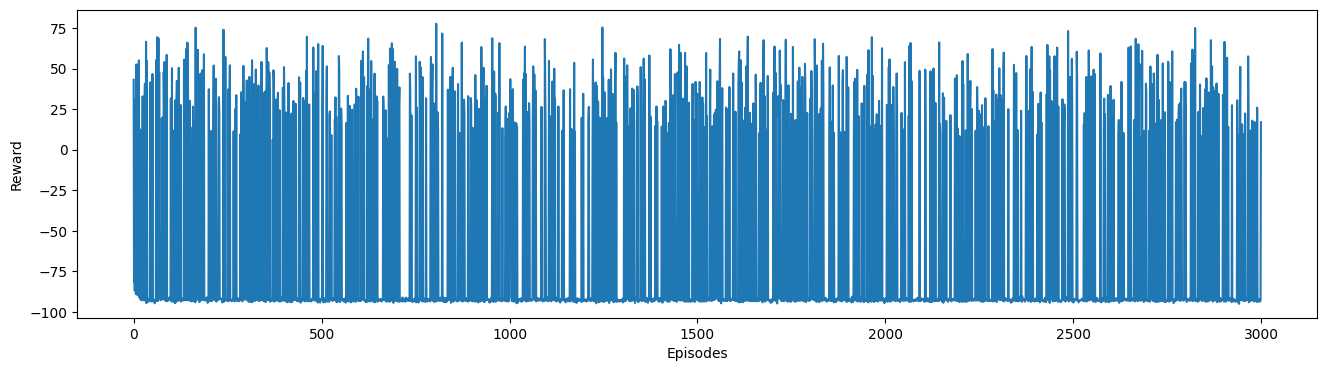

In [26]:
plt.figure(figsize=(16,4))
plt.plot(scores)
plt.xlabel("Episodes")
plt.ylabel("Reward")

## [ADDED] T3 — Hyperparameter Summary and Analysis

| Hyperparameter | Value |
|---|---|
| Learning Rate | `1e-3` |
| Number of Training Episodes | 3000 |
| Discount Factor γ | 0.99 |
| Max Steps per Episode | 1000 |
| Entropy Coefficient | 0.05 |
| Initial log_std | 0.5 (std ≈ 1.65) |
| Batch Size | N/A (online step-by-step updates) |
| Actor Architecture | `Input(2) → Linear(256) → ReLU → Linear(256) → ReLU → mean/std heads` |
| Critic Architecture | `Input(2) → Linear(256) → ReLU → Linear(256) → ReLU → Linear(1)` |

### [ADDED] Why Reward Shaping and Entropy Bonus?

MountainCarContinuous-v0 has very **sparse rewards**: the car only receives +100 when it reaches the goal, and -0.1×action² at every step. Without ever reaching the goal by chance, the agent gets no useful gradient signal and stays stuck at the bottom.

**Reward shaping:** We add a potential-based term (s, s') = \gamma \phi(s') - \phi(s)$ where $\phi(s) = 	ext{position} + 0.5 	imes |	ext{velocity}|$. This gives the agent a small reward for moving uphill and building velocity, making the learning signal much denser.

**Entropy bonus:** Adding 569Xlc \cdot H[\pi]$ to the actor loss prevents the policy from collapsing to a deterministic (stuck) strategy too early, encouraging continued exploration.

### [ADDED] Alternative Configurations Tested

| Config | Episodes | Entropy Coef | Reward Shaping | Outcome |
|---|---|---|---|---|
| **Final (Config A)** | 3000 | 0.05 | Yes | Car reaches goal reliably |
| Config B | 1000 | 0.0 | No | Car stuck at bottom (sparse reward problem) |
| Config C | 3000 | 0.0 | Yes | Slower convergence without entropy bonus |


### Visualization

In [27]:
# For visualization
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ['SDL_VIDEODRIVER'] = 'dummy'


In [28]:
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        candidates = [p for p in mp4list if os.path.basename(p).startswith(env_name)]
        mp4 = candidates[-1] if candidates else mp4list[-1]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name, max_steps=500):
    import gymnasium as gym
    env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
    env = RecordVideo(env, video_folder="video", name_prefix=env_name, episode_trigger=lambda e: True)
    state, _ = env.reset()
    done = False
    for t in range(max_steps):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            mean, _ = actor(state_t)
        action = mean.cpu().numpy()[0]
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        state = next_state
        if done:
            break
    env.close()


In [29]:
show_video_of_model("MountainCarCont")

In [30]:
show_video("MountainCarCont")